--- 1. Información General del Dataset ---
<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 7 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Age                    500 non-null    int64  
 1   Gender                 500 non-null    int64  
 2   BloodPressure          500 non-null    int64  
 3   Cholesterol            500 non-null    int64  
 4   HeartRate              500 non-null    int64  
 5   QuantumPatternFeature  500 non-null    float64
 6   HeartDisease           500 non-null    int64  
dtypes: float64(1), int64(6)
memory usage: 27.5 KB

--- 2. Conteo de Valores Nulos ---
Age                      0
Gender                   0
BloodPressure            0
Cholesterol              0
HeartRate                0
QuantumPatternFeature    0
HeartDisease             0
dtype: int64

--- 3. Estadística Descriptiva ---
              Age      Gender  BloodPressure  Cholesterol   HeartRate  

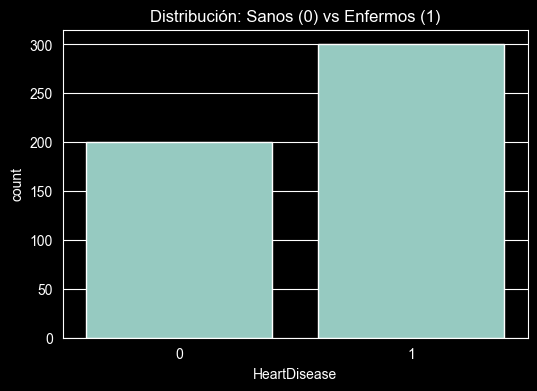

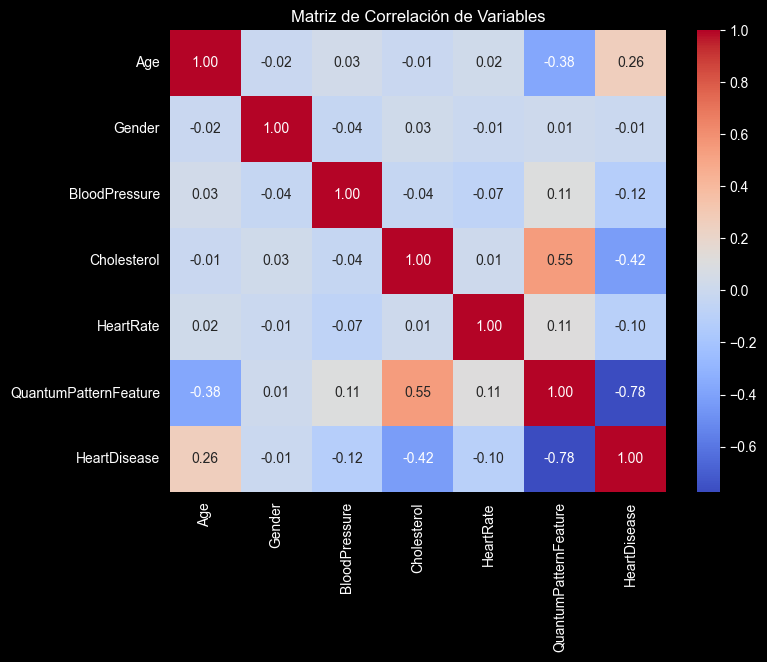


Iniciando el entrenamiento del modelo...

 RESULTADOS FINALES DE LA EVALUACIÓN
Accuracy (Exactitud):  93.00%
Precision (Precisión): 96.49%
Recall (Sensibilidad): 91.67%  <-- Métrica prioritaria
F1-Score:              94.02%


In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# 1. Cargar los Datos
df = pd.read_csv('Heart Prediction Quantum Dataset.csv')

# 2. Análisis Exploratorio de Datos (EDA)

print("--- 1. Información General del Dataset ---")
df.info()

print("\n--- 2. Conteo de Valores Nulos ---")
print(df.isnull().sum())

print("\n--- 3. Estadística Descriptiva ---")
print(df.describe())

# Visualización 1: Distribución de la variable a predecir
plt.figure(figsize=(6, 4))
sns.countplot(x='HeartDisease', data=df)
plt.title('Distribución: Sanos (0) vs Enfermos (1)')
plt.show()

# Visualización 2: Matriz de Correlación (relación matemática entre variables)
plt.figure(figsize=(8, 6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Matriz de Correlación de Variables')
plt.show()

# 3. Preprocesamiento de Datos

# Separar las características (X) y la variable objetivo (y)
X = df.drop('HeartDisease', axis=1)
y = df['HeartDisease']

# A. LabelEncoder para la variable objetivo (y)
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# B. OrdinalEncoder para las características categóricas en X (ej. Gender)
oe = OrdinalEncoder()
X['Gender'] = oe.fit_transform(X[['Gender']])


# 4. División de Datos
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42)


# 5. Construcción y Entrenamiento del Modelo
model = DecisionTreeClassifier(random_state=42)

print("\nIniciando el entrenamiento del modelo...")
model.fit(X_train, y_train)

# 6. Predicciones y Evaluación
y_pred = model.predict(X_test)

# Calcular las métricas
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

# Imprimir los resultados finales
print("\n" + "="*40)
print(" RESULTADOS FINALES DE LA EVALUACIÓN")
print("="*40)
print(f"Accuracy (Exactitud):  {accuracy * 100:.2f}%")
print(f"Precision (Precisión): {precision * 100:.2f}%")
print(f"Recall (Sensibilidad): {recall * 100:.2f}%  <-- Métrica prioritaria")
print(f"F1-Score:              {f1 * 100:.2f}%")
print("="*40)